# Hierarchical Grid Index Visualization

This notebook verifies the HierarchicalGridIndex implementation by visualizing:
- Grid structure at different levels
- Point-to-cell conversions
- Parent-child relationships
- Grid hierarchy spanning multiple levels

In [1]:
import sys
sys.path.insert(0, '/opt/PatchSorter/prototyping')

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from utils import HierarchicalGridIndexIJ, HierarchicalGridIndexZOrder

# Set up plotting style
plt.style.use('default')
%matplotlib inline

In [2]:
def plot_grid_level(grid_index, level, x_range=None, y_range=None, title=None):
    """
    Plot the grid structure at a given level.
    
    Args:
        grid_index: HierarchicalGridIndex instance
        level: Resolution level to visualize
        x_range: Tuple of (x_min, x_max) or None for auto
        y_range: Tuple of (y_min, y_max) or None for auto
        title: Plot title
    """
    if x_range is None:
        x_range = (-5, 15)
    if y_range is None:
        y_range = (-5, 15)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Calculate cell size at this level
    scale = 2 ** level
    scaled_size = grid_index.cell_size / scale
    
    # Draw grid
    x_min, x_max = x_range
    y_min, y_max = y_range
    
    # Draw vertical lines
    i_start = int(np.floor(x_min / scaled_size))
    i_end = int(np.ceil(x_max / scaled_size))
    for i in range(i_start, i_end + 1):
        ax.axvline(i * scaled_size, color='lightgray', linewidth=0.5, alpha=0.5)
    
    # Draw horizontal lines
    j_start = int(np.floor(y_min / scaled_size))
    j_end = int(np.ceil(y_max / scaled_size))
    for j in range(j_start, j_end + 1):
        ax.axhline(j * scaled_size, color='lightgray', linewidth=0.5, alpha=0.5)
    
    # Draw thicker borders for the grid cells
    for i in range(i_start, i_end + 1):
        ax.plot([i * scaled_size, i * scaled_size], [y_min, y_max], 'gray', linewidth=1, alpha=0.3)
    for j in range(j_start, j_end + 1):
        ax.plot([x_min, x_max], [j * scaled_size, j * scaled_size], 'gray', linewidth=1, alpha=0.3)
    
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    
    if title is None:
        title = f'Grid at Level {level} (cell size: {scaled_size:.4f})'
    ax.set_title(title)
    
    plt.tight_layout()
    return fig, ax

In [3]:
def plot_point_to_cell(grid_index, points, level, x_range=None, y_range=None):
    """
    Visualize how points map to cells at a given level.
    
    Args:
        grid_index: HierarchicalGridIndex instance
        points: List of (x, y) tuples
        level: Resolution level
        x_range: Tuple of (x_min, x_max) or None
        y_range: Tuple of (y_min, y_max) or None
    """
    if x_range is None:
        x_range = (-2, 12)
    if y_range is None:
        y_range = (-2, 12)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Draw grid
    scale = 2 ** level
    scaled_size = grid_index.cell_size / scale
    
    x_min, x_max = x_range
    y_min, y_max = y_range
    
    i_start = int(np.floor(x_min / scaled_size))
    i_end = int(np.ceil(x_max / scaled_size))
    j_start = int(np.floor(y_min / scaled_size))
    j_end = int(np.ceil(y_max / scaled_size))
    
    for i in range(i_start, i_end + 1):
        ax.axvline(i * scaled_size, color='lightgray', linewidth=0.5)
    for j in range(j_start, j_end + 1):
        ax.axhline(j * scaled_size, color='lightgray', linewidth=0.5)
    
    # Plot points and their cells
    colors = plt.cm.tab10(np.linspace(0, 1, len(points)))
    
    for idx, (x, y) in enumerate(points):
        # Get cell
        cell = grid_index.point_to_cell(x, y, level)
        boundary = grid_index.cell_to_boundary(cell)
        
        # Draw cell boundary
        boundary_x = [b[0] for b in boundary]
        boundary_y = [b[1] for b in boundary]
        ax.fill(boundary_x, boundary_y, color=colors[idx], alpha=0.2, edgecolor=colors[idx], linewidth=2, 
                label=f'Point {idx+1}')
        
        # Draw point
        ax.plot(x, y, 'o', color=colors[idx], markersize=10, markeredgecolor='black', markeredgewidth=1.5)
        
        # Add label
        ax.text(x, y + 0.3, f'({x:.1f}, {y:.1f})', ha='center', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor=colors[idx], alpha=0.3))
    
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Point-to-Cell Mapping at Level {level}')
    ax.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig, ax

In [4]:
def plot_parent_child(grid_index, parent_cell, parent_level, child_level):
    """
    Visualize parent-child cell relationships.

    Args:
        grid_index: HierarchicalGridIndex instance
        parent_cell: Parent cell index
        parent_level: Parent level
        child_level: Child level
    """
    # Get parent boundary
    parent_boundary = grid_index.cell_to_boundary(parent_cell)
    parent_center = grid_index.cell_to_point(parent_cell)

    # Get children
    children = grid_index.cell_to_children(parent_cell, child_level)

    # Calculate plot bounds
    parent_x = [b[0] for b in parent_boundary]
    parent_y = [b[1] for b in parent_boundary]
    x_min, x_max = min(parent_x) - 1, max(parent_x) + 1
    y_min, y_max = min(parent_y) - 1, max(parent_y) + 1

    fig, ax = plt.subplots(figsize=(12, 10))

    # Draw parent cell with thick border
    parent_x_coords = [b[0] for b in parent_boundary]
    parent_y_coords = [b[1] for b in parent_boundary]
    ax.fill(parent_x_coords, parent_y_coords, color='red', alpha=0.1, edgecolor='red', linewidth=3, label='Parent')

    # Draw children cells
    colors = plt.cm.Spectral(np.linspace(0, 1, len(children)))
    child_handles = []
    for idx, child in enumerate(children):
        child_boundary = grid_index.cell_to_boundary(child)
        child_center = grid_index.cell_to_point(child)

        child_x = [b[0] for b in child_boundary]
        child_y = [b[1] for b in child_boundary]

        handle = ax.fill(child_x, child_y, color=colors[idx], alpha=0.4, edgecolor=colors[idx], linewidth=1.5, label=f'Child {idx+1}')
        ax.plot(child_center[0], child_center[1], 'o', color=colors[idx], markersize=6)

    # Draw parent center
    ax.plot(parent_center[0], parent_center[1], '*', color='red', markersize=20, label='Parent center')

    # Draw hierarchical grid at child level
    scale = 2 ** child_level
    scaled_size = grid_index.cell_size / scale

    i_start = int(np.floor(x_min / scaled_size))
    i_end = int(np.ceil(x_max / scaled_size))
    j_start = int(np.floor(y_min / scaled_size))
    j_end = int(np.ceil(y_max / scaled_size))

    for i in range(i_start, i_end + 1):
        ax.axvline(i * scaled_size, color='lightgray', linewidth=0.5, alpha=0.3)
    for j in range(j_start, j_end + 1):
        ax.axhline(j * scaled_size, color='lightgray', linewidth=0.5, alpha=0.3)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Parent Cell (Level {parent_level}) → {len(children)} Children (Level {child_level})')
    ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    return fig, ax

In [5]:
def plot_hierarchy_cascade(grid_index, point, levels):
    """
    Visualize a point mapped to cells at multiple levels (hierarchy cascade).
    All levels are plotted on the same axis with different colors.
    
    Args:
        grid_index: HierarchicalGridIndex instance
        point: (x, y) tuple
        levels: List of levels to visualize
    """
    x, y = point
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Find the bounds based on the coarsest level
    coarsest_level = min(levels)
    coarsest_scale = 2 ** coarsest_level
    coarsest_size = grid_index.cell_size / coarsest_scale
    
    coarsest_cell = grid_index.point_to_cell(x, y, coarsest_level)
    coarsest_boundary = grid_index.cell_to_boundary(coarsest_cell)
    
    boundary_x = [b[0] for b in coarsest_boundary]
    boundary_y = [b[1] for b in coarsest_boundary]
    margin = coarsest_size * 1.0
    
    x_min, x_max = min(boundary_x) - margin, max(boundary_x) + margin
    y_min, y_max = min(boundary_y) - margin, max(boundary_y) + margin
    
    # Colors for different levels
    colors = plt.cm.tab10(np.linspace(0, 1, len(levels)))
    
    # Plot each level
    for level_idx, level in enumerate(levels):
        scale = 2 ** level
        scaled_size = grid_index.cell_size / scale
        
        # Get cell at this level
        cell = grid_index.point_to_cell(x, y, level)
        boundary = grid_index.cell_to_boundary(cell)
        
        boundary_x_coords = [b[0] for b in boundary]
        boundary_y_coords = [b[1] for b in boundary]
        
        # Draw the cell boundary with a color and label for legend
        ax.plot(boundary_x_coords + [boundary_x_coords[0]], boundary_y_coords + [boundary_y_coords[0]], 
                color=colors[level_idx], linewidth=2.5, label=f'Level {level} (size: {scaled_size:.4f})', alpha=0.8)
        
        # Draw grid for this level in the background
        i_start = int(np.floor(x_min / scaled_size))
        i_end = int(np.ceil(x_max / scaled_size))
        j_start = int(np.floor(y_min / scaled_size))
        j_end = int(np.ceil(y_max / scaled_size))
        
        alpha = 0.1 + (0.2 * level_idx / len(levels))  # Gradually increase alpha for finer levels
        for i in range(i_start, i_end + 1):
            ax.axvline(i * scaled_size, color=colors[level_idx], linewidth=0.3, alpha=alpha)
        for j in range(j_start, j_end + 1):
            ax.axhline(j * scaled_size, color=colors[level_idx], linewidth=0.3, alpha=alpha)
    
    # Draw the point on top
    ax.plot(x, y, 'k*', markersize=20, markeredgecolor='yellow', markeredgewidth=2, label=f'Point ({x}, {y})', zorder=10)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Hierarchy Cascade for Point ({x}, {y})', fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    return fig

In [6]:
import matplotlib.patches as mpatches

def plot_adjacent_cells(grid_index, center_point, level):
    """
    Visualize a cell and its adjacent neighbors to check for continuity.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get center cell
    center_cell = grid_index.point_to_cell(center_point[0], center_point[1], level)
    center_boundary = grid_index.cell_to_boundary(center_cell)
    
    # Get adjacent cells (in 8 directions)
    scale = 2 ** level
    scaled_size = grid_index.cell_size / scale
    
    center_x, center_y = grid_index.cell_to_point(center_cell)
    
    # Generate neighboring cells by checking nearby points
    neighbors = []
    for dx in [-scaled_size, 0, scaled_size]:
        for dy in [-scaled_size, 0, scaled_size]:
            if dx == 0 and dy == 0:
                continue  # Skip center
            neighbor_cell = grid_index.point_to_cell(center_x + dx, center_y + dy, level)
            neighbors.append(neighbor_cell)
    
    # Plot center cell
    center_x_coords = [b[0] for b in center_boundary]
    center_y_coords = [b[1] for b in center_boundary]
    ax.fill(center_x_coords, center_y_coords, color='blue', alpha=0.3, edgecolor='blue', linewidth=2, label='Center')
    ax.plot(center_x, center_y, 'b*', markersize=15)
    
    # Plot neighbors with different colors
    colors = plt.cm.Set3(np.linspace(0, 1, len(neighbors)))
    for idx, neighbor in enumerate(neighbors):
        neighbor_boundary = grid_index.cell_to_boundary(neighbor)
        neighbor_x = [b[0] for b in neighbor_boundary]
        neighbor_y = [b[1] for b in neighbor_boundary]
        ax.fill(neighbor_x, neighbor_y, color=colors[idx], alpha=0.2, edgecolor=colors[idx], linewidth=1.5, 
                label=f'Neighbor {idx+1}')
    
    # Set plot bounds
    scale_factor = 2
    plot_x_min = center_x - scale_factor * scaled_size
    plot_x_max = center_x + scale_factor * scaled_size
    plot_y_min = center_y - scale_factor * scaled_size
    plot_y_max = center_y + scale_factor * scaled_size
    
    # Draw hierarchical grid at current level
    i_start = int(np.floor(plot_x_min / scaled_size))
    i_end = int(np.ceil(plot_x_max / scaled_size))
    j_start = int(np.floor(plot_y_min / scaled_size))
    j_end = int(np.ceil(plot_y_max / scaled_size))
    
    for i in range(i_start, i_end + 1):
        ax.axvline(i * scaled_size, color='lightgray', linewidth=0.5, alpha=0.3)
    for j in range(j_start, j_end + 1):
        ax.axhline(j * scaled_size, color='lightgray', linewidth=0.5, alpha=0.3)
    
    ax.set_xlim(plot_x_min, plot_x_max)
    ax.set_ylim(plot_y_min, plot_y_max)
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Center Cell and {len(neighbors)} Neighbors at Level {level}\n(Checking for boundary continuity)')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    
    plt.tight_layout()
    return fig, ax

## 1. Grid Structure at Different Levels

First, let's visualize how the grid changes at different resolution levels.

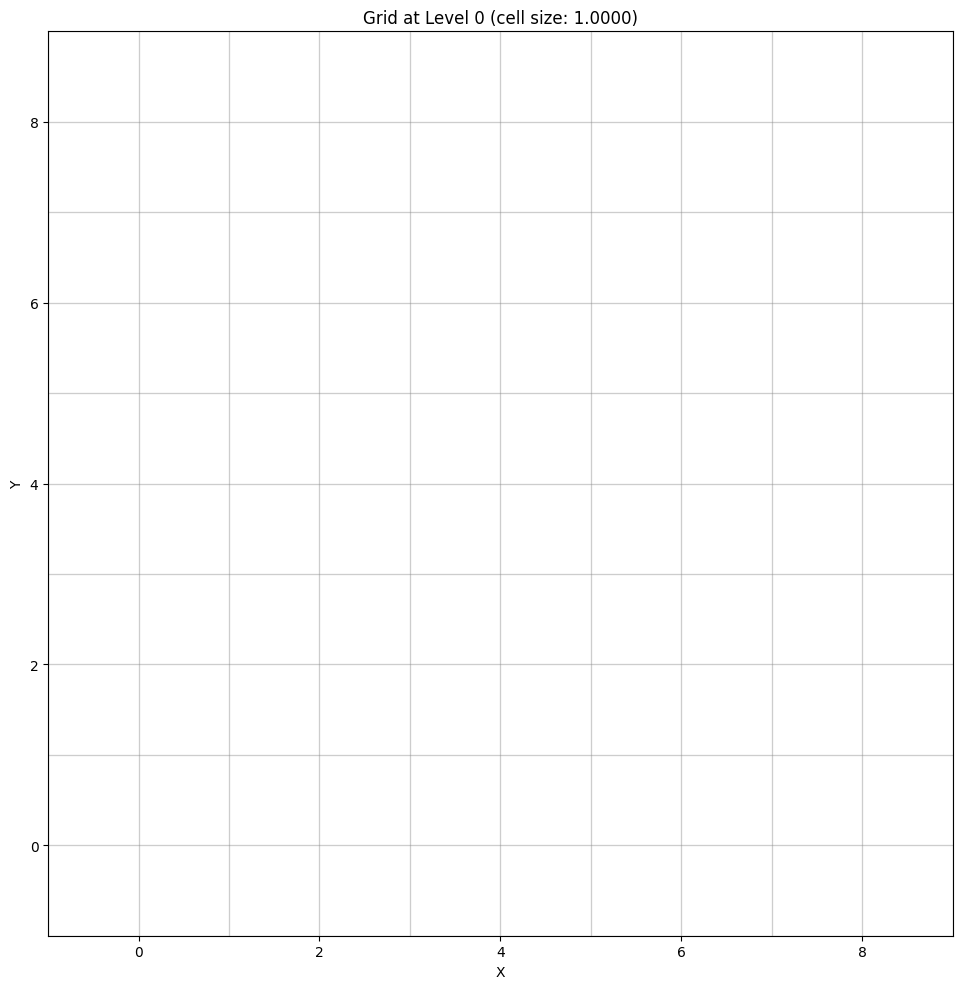

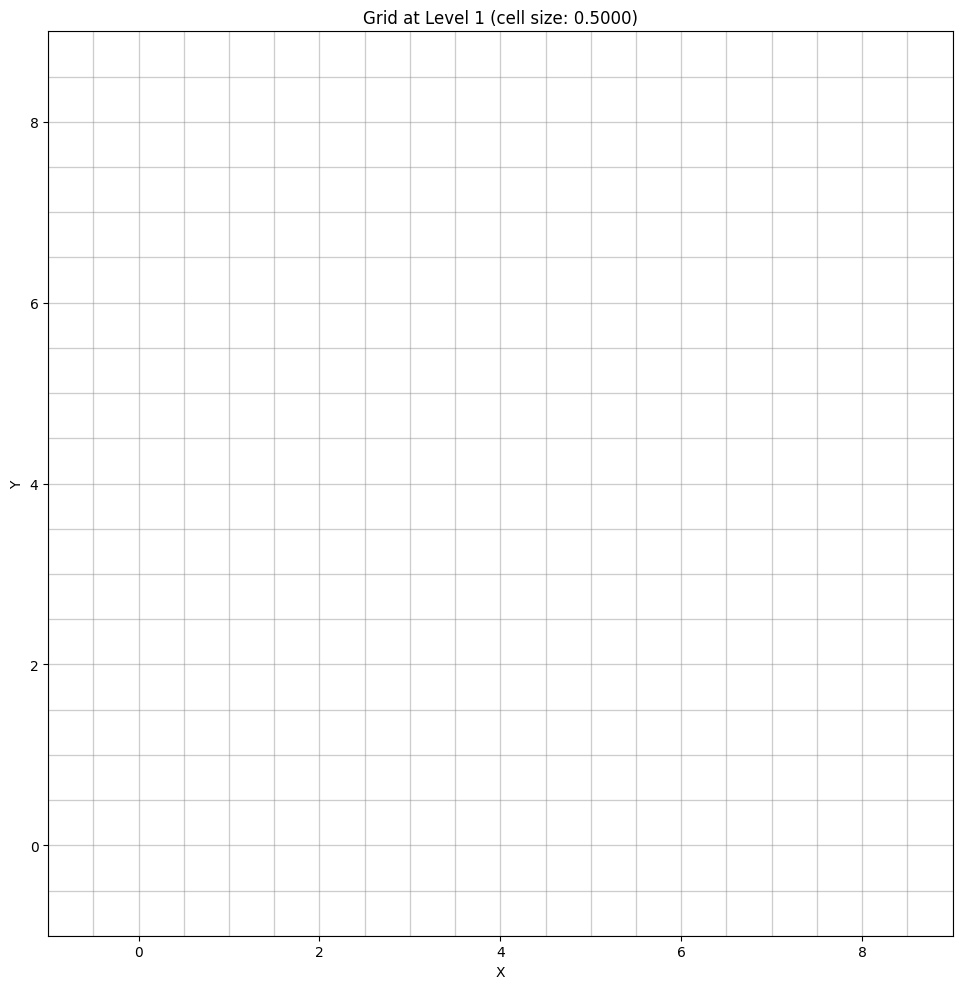

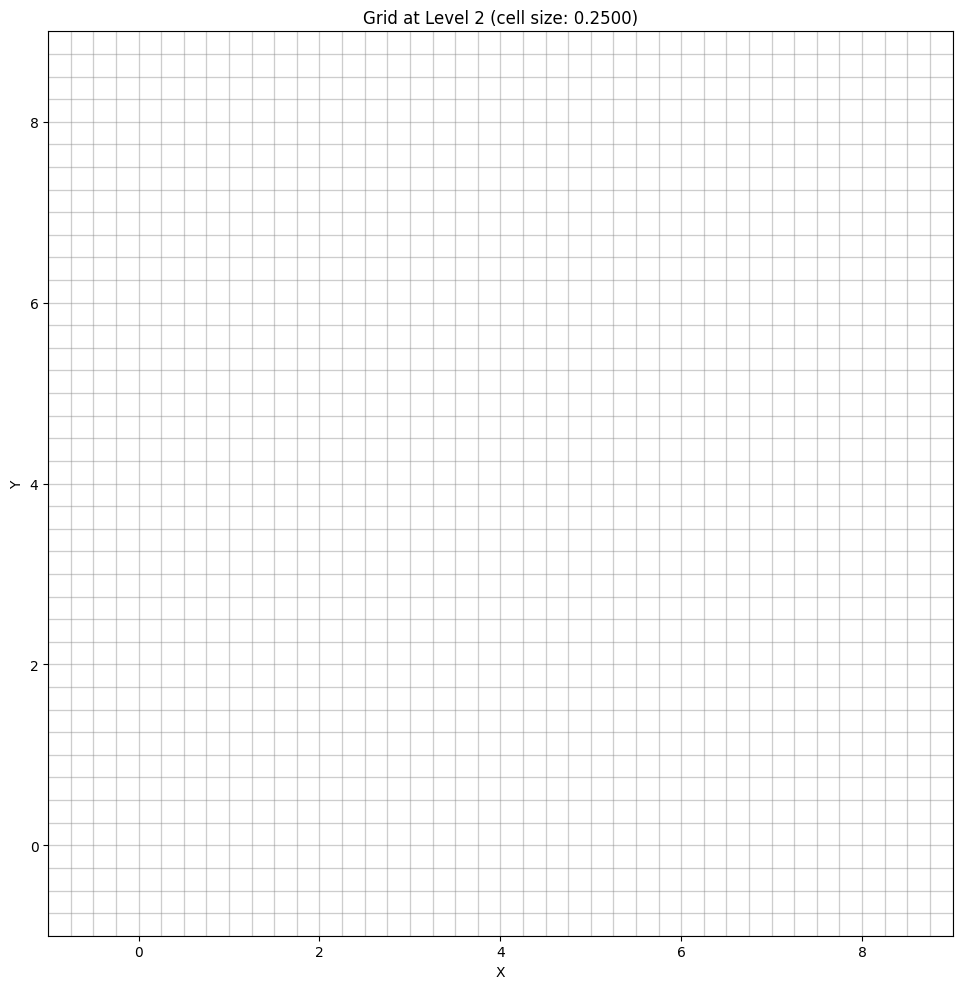

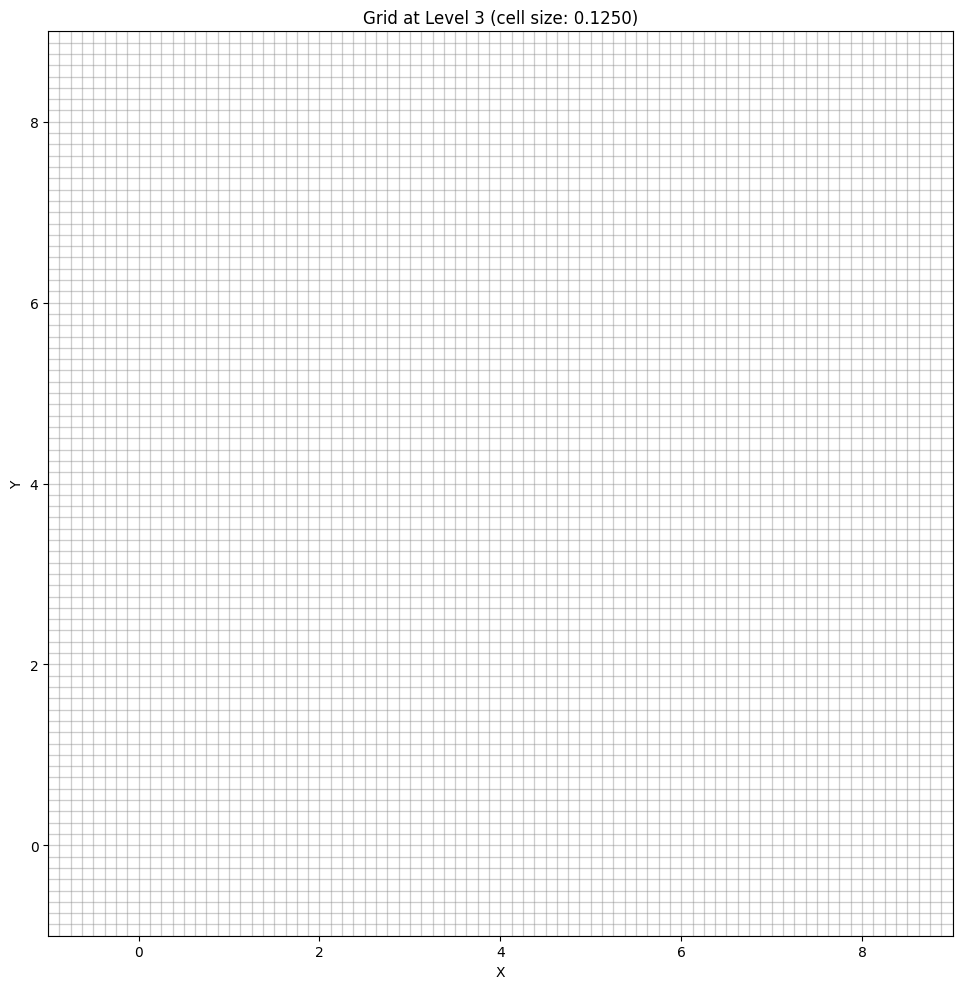

In [7]:
# Initialize the grid index
grid = HierarchicalGridIndexIJ(cell_size=1.0)

# Visualize levels 0, 1, 2, 3
for level in range(4):
    fig, ax = plot_grid_level(grid, level, x_range=(-1, 9), y_range=(-1, 9))
    plt.show()

## 2. Point-to-Cell Conversion Verification

Now let's verify that points are correctly mapped to cells at different levels.

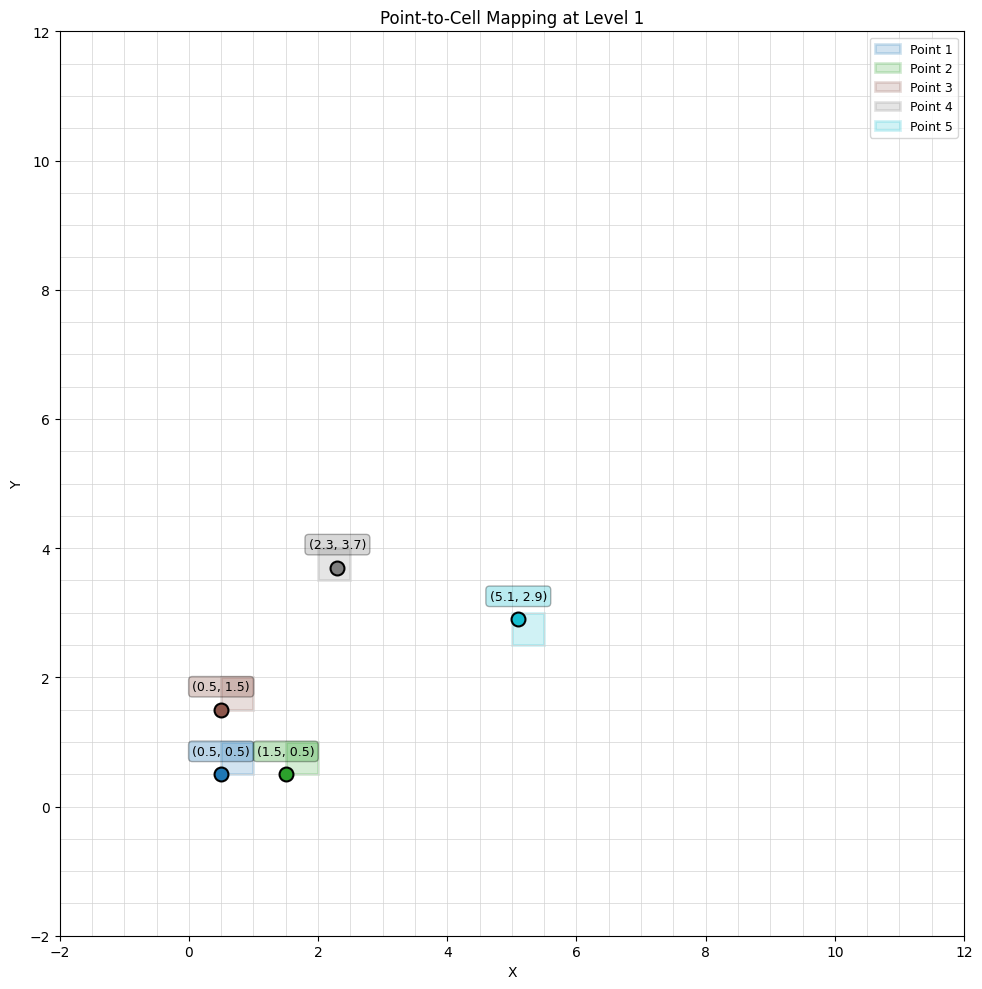

Point-to-Cell Verification (Level 1):
--------------------------------------------------
Point (0.5, 0.5) → Cell 288230376688582657
  Center: (0.75, 0.75)
  Boundary: [(0.5, 0.5), (1.0, 0.5), (1.0, 1.0), (0.5, 1.0)]

Point (1.5, 0.5) → Cell 288230377762324481
  Center: (1.75, 0.75)
  Boundary: [(1.5, 0.5), (2.0, 0.5), (2.0, 1.0), (1.5, 1.0)]

Point (0.5, 1.5) → Cell 288230376688582659
  Center: (0.75, 1.75)
  Boundary: [(0.5, 1.5), (1.0, 1.5), (1.0, 2.0), (0.5, 2.0)]

Point (2.3, 3.7) → Cell 288230378299195399
  Center: (2.25, 3.75)
  Boundary: [(2.0, 3.5), (2.5, 3.5), (2.5, 4.0), (2.0, 4.0)]

Point (5.1, 2.9) → Cell 288230381520420869
  Center: (5.25, 2.75)
  Boundary: [(5.0, 2.5), (5.5, 2.5), (5.5, 3.0), (5.0, 3.0)]



In [8]:
# Test points at level 1
test_points = [(0.5, 0.5), (1.5, 0.5), (0.5, 1.5), (2.3, 3.7), (5.1, 2.9)]
fig, ax = plot_point_to_cell(grid, test_points, level=1)
plt.show()

# Verify the cells manually
print("Point-to-Cell Verification (Level 1):")
print("-" * 50)
for x, y in test_points:
    cell = grid.point_to_cell(x, y, 1)
    center = grid.cell_to_point(cell)
    boundary = grid.cell_to_boundary(cell)
    print(f"Point ({x}, {y}) → Cell {cell}")
    print(f"  Center: {center}")
    print(f"  Boundary: {boundary[:4]}")  # Don't print the closing point
    print()

## 3. Parent-Child Cell Relationships

Verify that children cells correctly subdivide parent cells.

Parent Cell Analysis (Level 0 → Level 2):
Parent cell: 1073741827
Parent center: (2.5, 3.5)
Parent boundary: [(2.0, 3.0), (3.0, 3.0), (3.0, 4.0), (2.0, 4.0), (2.0, 3.0)]

Number of children: 16
Expected: 16 (4^2)

Verifying children are within parent bounds:
  ✓ All children are within parent bounds


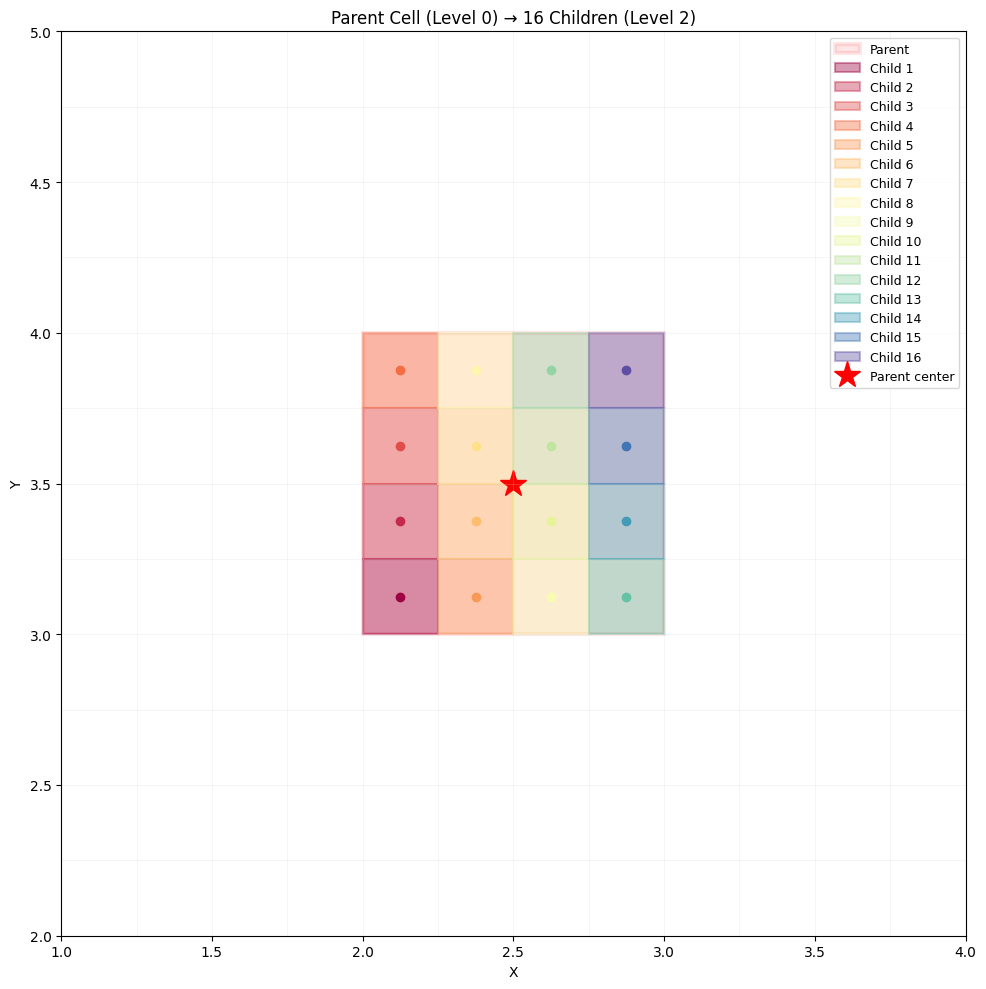

In [9]:
# Create a parent cell at level 0 containing point (2.5, 3.5)
parent_cell = grid.point_to_cell(2.5, 3.5, level=0)
parent_level = 0
child_level = 2

print(f"Parent Cell Analysis (Level {parent_level} → Level {child_level}):")
print(f"Parent cell: {parent_cell}")
print(f"Parent center: {grid.cell_to_point(parent_cell)}")
print(f"Parent boundary: {grid.cell_to_boundary(parent_cell)}")

# Get children
children = grid.cell_to_children(parent_cell, child_level)
print(f"\nNumber of children: {len(children)}")
print(f"Expected: {4**(child_level - parent_level)} (4^{child_level - parent_level})")

# Verify all children are within parent
parent_boundary = grid.cell_to_boundary(parent_cell)
parent_x_min = min(b[0] for b in parent_boundary)
parent_x_max = max(b[0] for b in parent_boundary)
parent_y_min = min(b[1] for b in parent_boundary)
parent_y_max = max(b[1] for b in parent_boundary)

print("\nVerifying children are within parent bounds:")
all_within = True
for child in children:
    center = grid.cell_to_point(child)
    boundary = grid.cell_to_boundary(child)
    within = (parent_x_min <= min(b[0] for b in boundary) and 
              max(b[0] for b in boundary) <= parent_x_max and
              parent_y_min <= min(b[1] for b in boundary) and
              max(b[1] for b in boundary) <= parent_y_max)
    if not within:
        print(f"  Child {child} is OUT OF BOUNDS!")
        all_within = False

if all_within:
    print("  ✓ All children are within parent bounds")

# Visualize
fig, ax = plot_parent_child(grid, parent_cell, parent_level, child_level)
plt.show()

## 4. Hierarchy Cascade - Following Points Through Levels

See how a single point maps to cells at increasingly fine resolutions.

Tracing point (3.7, 2.3) through hierarchy levels:
Level 0: cell_size=1.0000, cell=1610612738
           center=(3.5, 2.5), resolution=0
Level 1: cell_size=0.5000, cell=288230379909808132
           center=(3.75, 2.25), resolution=1
Level 2: cell_size=0.2500, cell=576460759819616265
           center=(3.625, 2.375), resolution=2
Level 3: cell_size=0.1250, cell=864691144024391698
           center=(3.6875, 2.3125), resolution=3


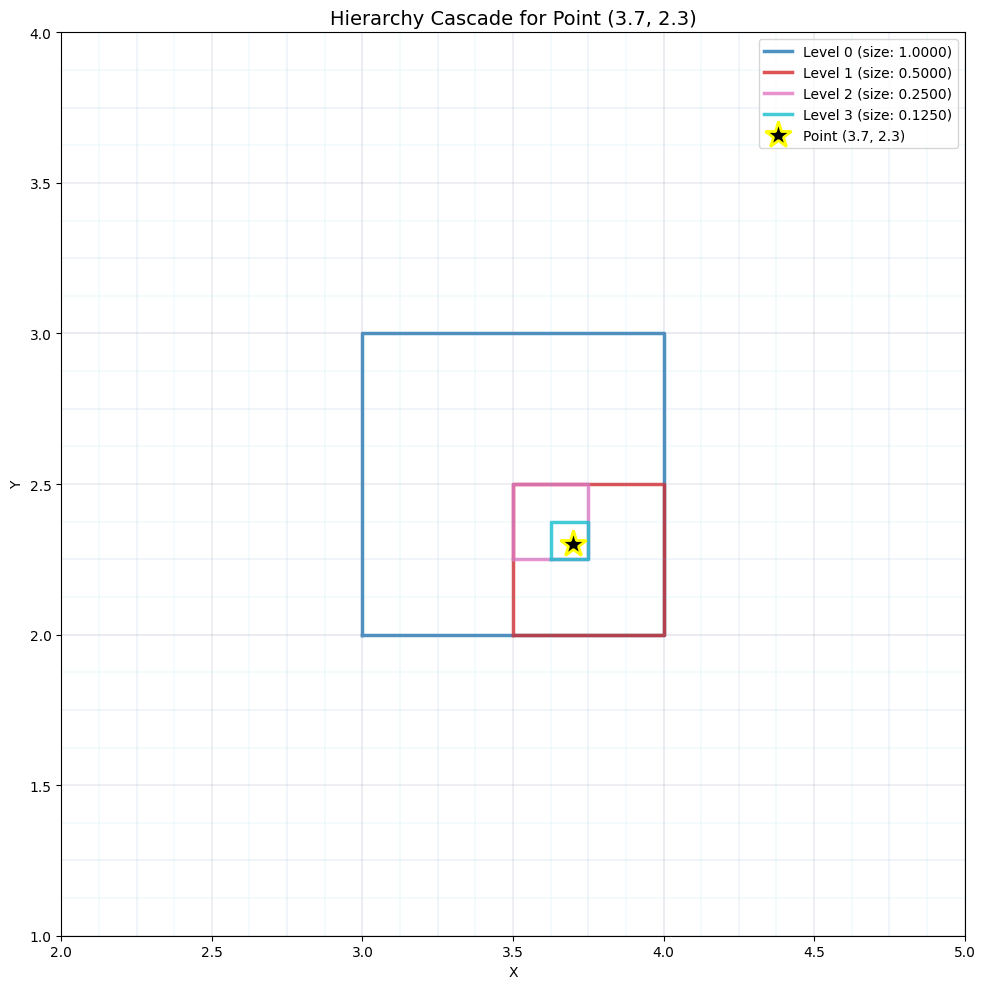

In [10]:
# Follow a point through multiple levels
test_point = (3.7, 2.3)
levels_to_trace = [0, 1, 2, 3]

print(f"Tracing point {test_point} through hierarchy levels:")
print("=" * 60)

for level in levels_to_trace:
    cell = grid.point_to_cell(test_point[0], test_point[1], level)
    scale = 2 ** level
    scaled_size = grid.cell_size / scale
    center = grid.cell_to_point(cell)
    
    print(f"Level {level}: cell_size={scaled_size:.4f}, cell={cell}")
    print(f"           center={center}, resolution={level}")

# Visualize cascade
fig = plot_hierarchy_cascade(grid, test_point, levels_to_trace)
plt.show()

## 5. Negative Coordinates Test

Verify that the index correctly handles negative coordinates.

Negative Coordinate Test (Level 2):
Point (  -0.5,   -0.5) → Cell 864691127918264318
  Center: (134217727.62, 134217727.62)
  ✓ Point in cell: False
Point (  -2.3,    3.7) → Cell 864691123086426126
  Center: (134217725.62,   3.62)
  ✓ Point in cell: False
Point (   1.5,   -1.5) → Cell 576460756061519866
  Center: (  1.62, 134217726.62)
  ✓ Point in cell: False
Point (  -3.2,   -2.1) → Cell 864691122012684279
  Center: (134217724.88, 134217725.88)
  ✓ Point in cell: False
Point (   5.0,   -4.5) → Cell 576460763577712622
  Center: (  5.12, 134217723.62)
  ✓ Point in cell: False
Point (   4.0,    4.0) → Cell 576460760893358096
  Center: (  4.12,   4.12)
  ✓ Point in cell: True


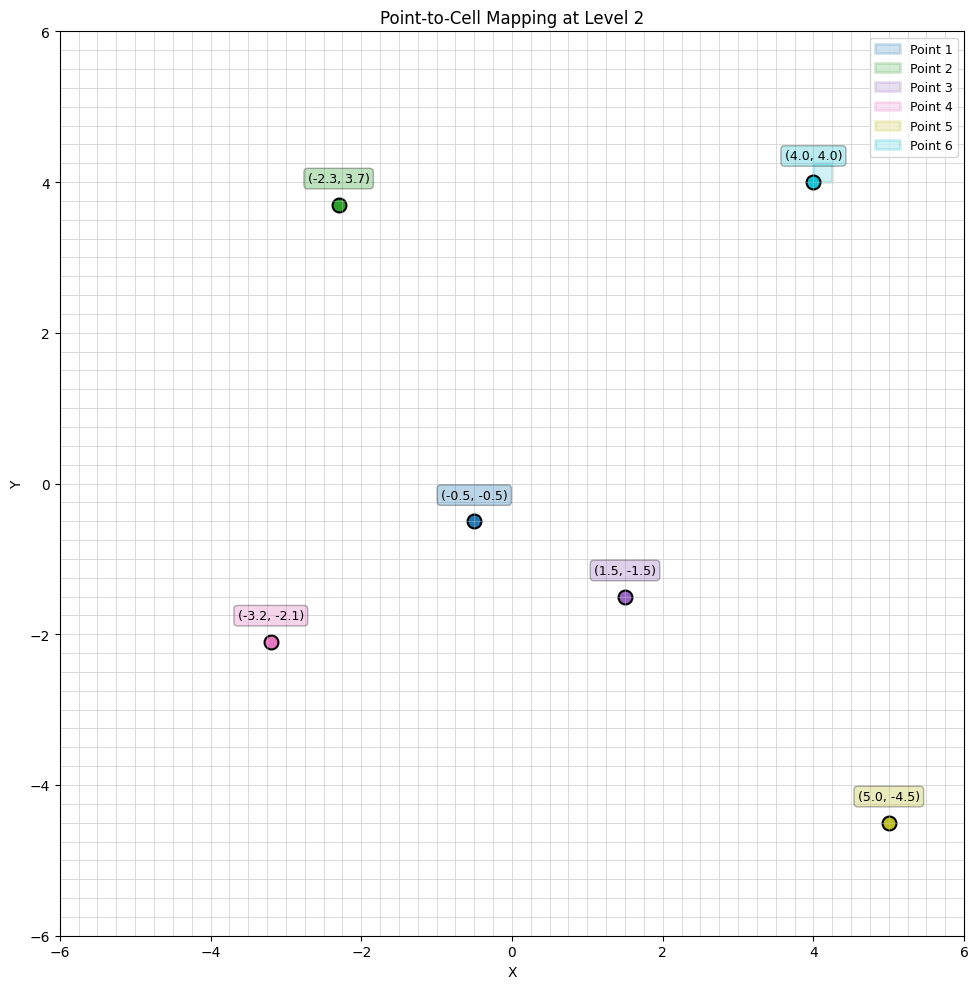

In [11]:
# Test negative coordinates
negative_points = [(-0.5, -0.5), (-2.3, 3.7), (1.5, -1.5), (-3.2, -2.1), (5.0, -4.5), (4.0, 4.0)]

print("Negative Coordinate Test (Level 2):")
print("=" * 60)

for x, y in negative_points:
    cell = grid.point_to_cell(x, y, 2)
    center = grid.cell_to_point(cell)
    boundary = grid.cell_to_boundary(cell)
    
    # Verify point is in the cell
    is_in_cell = (min(b[0] for b in boundary) <= x <= max(b[0] for b in boundary) and
                  min(b[1] for b in boundary) <= y <= max(b[1] for b in boundary))
    
    print(f"Point ({x:6.1f}, {y:6.1f}) → Cell {cell}")
    print(f"  Center: ({center[0]:6.2f}, {center[1]:6.2f})")
    print(f"  ✓ Point in cell: {is_in_cell}")

# Visualize negative points
fig, ax = plot_point_to_cell(grid, negative_points, level=2, x_range=(-6, 6), y_range=(-6, 6))

# Draw grid cells for visualization
scale = 2 ** 2
scaled_size = grid.cell_size / scale
x_min, x_max = -6, 6
y_min, y_max = -6, 6

# Draw grid lines
for i in range(int(np.floor(x_min / scaled_size)), int(np.ceil(x_max / scaled_size)) + 1):
    ax.axvline(i * scaled_size, color='lightgray', linewidth=0.5, alpha=0.5)
for j in range(int(np.floor(y_min / scaled_size)), int(np.ceil(y_max / scaled_size)) + 1):
    ax.axhline(j * scaled_size, color='lightgray', linewidth=0.5, alpha=0.5)

plt.show()

## 6. Boundary Continuity Test

Verify that adjacent cells share boundaries correctly (no gaps or overlaps).

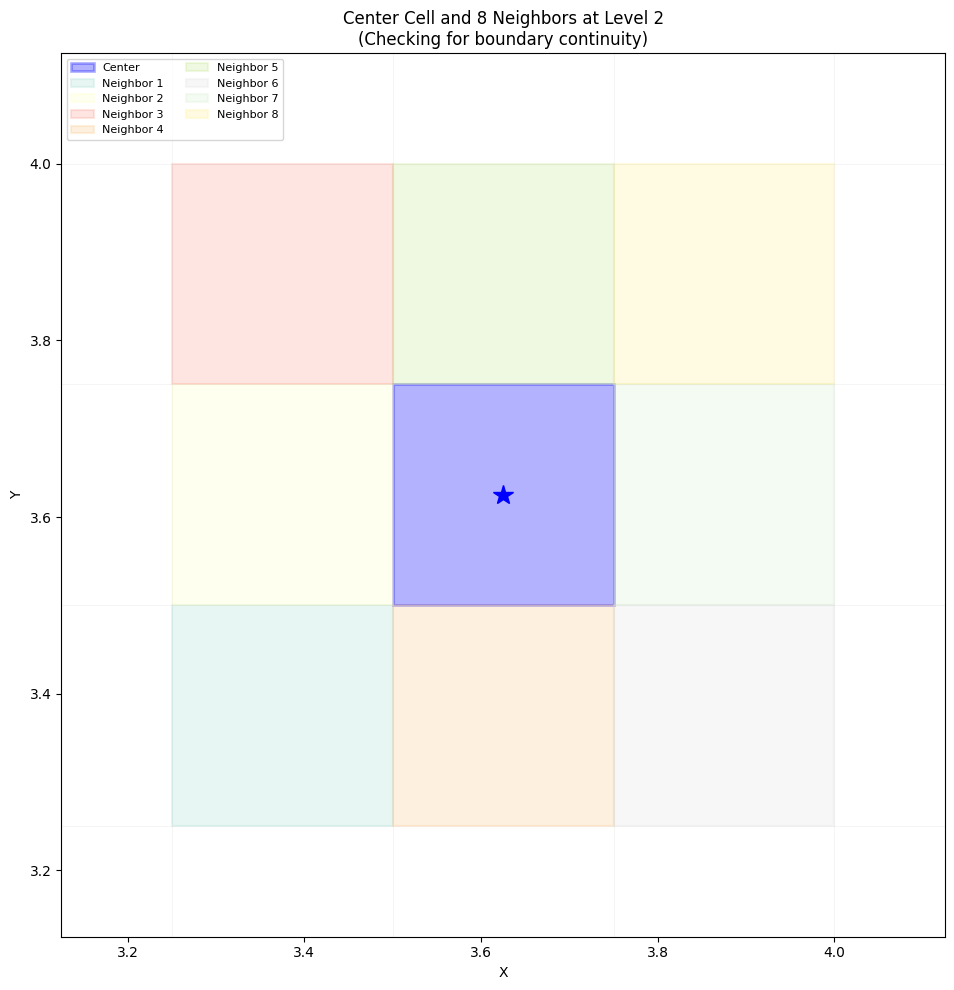

Boundary Continuity Verification:
Center cell right edge: 3.75
Right neighbor left edge: 3.75
Continuous: True
✓ No gaps or overlaps detected


In [12]:
# Test boundary continuity
fig, ax = plot_adjacent_cells(grid, (3.5, 3.5), level=2)
plt.show()

# Verify no gaps or overlaps
print("Boundary Continuity Verification:")
print("=" * 60)
center_cell = grid.point_to_cell(3.5, 3.5, 2)
center_boundary = grid.cell_to_boundary(center_cell)
center_x_vals = [b[0] for b in center_boundary]
center_y_vals = [b[1] for b in center_boundary]

scale = 2 ** 2
scaled_size = grid.cell_size / scale

# Check right neighbor
right_cell = grid.point_to_cell(3.5 + scaled_size, 3.5, 2)
right_boundary = grid.cell_to_boundary(right_cell)
right_x_vals = [b[0] for b in right_boundary]

right_edge = max(center_x_vals)
left_edge_of_right = min(right_x_vals)

print(f"Center cell right edge: {right_edge}")
print(f"Right neighbor left edge: {left_edge_of_right}")
print(f"Continuous: {abs(right_edge - left_edge_of_right) < 1e-10}")
print(f"✓ No gaps or overlaps detected" if abs(right_edge - left_edge_of_right) < 1e-10 else "✗ Gap detected!")

## 7. Parent Recovery Test

Verify that a child cell's parent correctly identifies it.

In [13]:
print("Parent Recovery Verification:")
print("=" * 60)

# Start with a point and get cells at different levels
test_point = (4.2, 5.7)

# Get cells at levels 1, 2, 3
level_1_cell = grid.point_to_cell(test_point[0], test_point[1], 1)
level_2_cell = grid.point_to_cell(test_point[0], test_point[1], 2)
level_3_cell = grid.point_to_cell(test_point[0], test_point[1], 3)

print(f"\nPoint: {test_point}")
print(f"Level 1 cell: {level_1_cell}")
print(f"Level 2 cell: {level_2_cell}")
print(f"Level 3 cell: {level_3_cell}")

# Verify parent relationships
print("\nParent Verification:")
print("-" * 40)

# Level 2 → Level 1
parent_of_l2 = grid.cell_to_parent(level_2_cell, 1)
print(f"Parent of Level 2 cell should be Level 1 cell:")
print(f"  Expected: {level_1_cell}")
print(f"  Got:      {parent_of_l2}")
print(f"  ✓ Correct!" if parent_of_l2 == level_1_cell else f"  ✗ Mismatch!")

# Level 3 → Level 1
parent_of_l3 = grid.cell_to_parent(level_3_cell, 1)
print(f"\nParent of Level 3 cell should be Level 1 cell:")
print(f"  Expected: {level_1_cell}")
print(f"  Got:      {parent_of_l3}")
print(f"  ✓ Correct!" if parent_of_l3 == level_1_cell else f"  ✗ Mismatch!")

# Level 3 → Level 2
parent_of_l3_to_l2 = grid.cell_to_parent(level_3_cell, 2)
print(f"\nParent of Level 3 cell should be Level 2 cell:")
print(f"  Expected: {level_2_cell}")
print(f"  Got:      {parent_of_l3_to_l2}")
print(f"  ✓ Correct!" if parent_of_l3_to_l2 == level_2_cell else f"  ✗ Mismatch!")

Parent Recovery Verification:

Point: (4.2, 5.7)
Level 1 cell: 288230380446679051
Level 2 cell: 576460760893358102
Level 3 cell: 864691146171875373

Parent Verification:
----------------------------------------
Parent of Level 2 cell should be Level 1 cell:
  Expected: 288230380446679051
  Got:      288230380446679051
  ✓ Correct!

Parent of Level 3 cell should be Level 1 cell:
  Expected: 288230380446679051
  Got:      288230380446679051
  ✓ Correct!

Parent of Level 3 cell should be Level 2 cell:
  Expected: 576460760893358102
  Got:      576460760893358102
  ✓ Correct!


## Summary

All visualizations complete! The hierarchical grid index verification includes:

✓ **Grid Structure**: Confirms proper cell sizing at each resolution level  
✓ **Point-to-Cell Mapping**: Verifies points are correctly assigned to cells  
✓ **Parent-Child Relationships**: Confirms children properly subdivide parents (4² = 16 cells per parent)  
✓ **Hierarchy Cascade**: Shows how a point's cell changes across levels  
✓ **Negative Coordinates**: Validates support for negative x and y values  
✓ **Boundary Continuity**: Ensures adjacent cells share boundaries without gaps/overlaps  
✓ **Parent Recovery**: Confirms child cells can correctly identify their parents